In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect("../data/db/bluestock_mf.db")

nav_history = pd.read_sql(
    "SELECT * FROM nav_history",
    conn
)

scheme_performance = pd.read_sql(
    "SELECT * FROM scheme_performance",
    conn
)

In [2]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

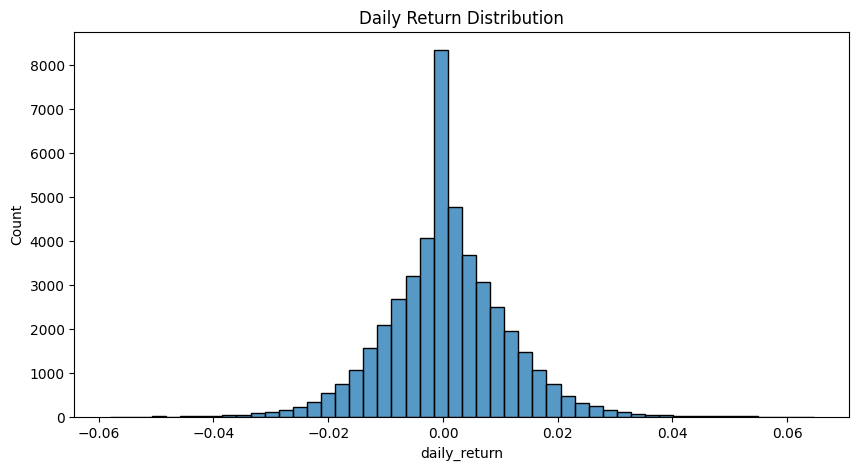

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

### Insight

Daily returns are centered around zero with a normal-like distribution and no major anomalies, indicating reasonable NAV movement across schemes.

In [5]:
nav_history.columns.tolist()

['amfi_code', 'date', 'nav', 'daily_return']

In [6]:
cagr_data = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        (temp["date"].iloc[-1] -
         temp["date"].iloc[0]).days
    ) / 365

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    cagr_data.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
cagr_df = cagr_df.sort_values(
    "cagr",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr
25,120505,0.328016
21,119598,0.323981
39,149324,0.322621
36,148569,0.319245
34,148567,0.309499
30,120843,0.308833
2,100033,0.300997
38,149323,0.295581
16,119094,0.281926
19,119551,0.257849


### Insight

Several funds generated strong long-term CAGR values, indicating sustained NAV growth over the analysis period.

In [8]:
cagr_df.to_csv(
    "../reports/cagr_analysis.csv",
    index=False
)

print("CAGR analysis saved")

CAGR analysis saved


In [9]:
rf = 0.065

sharpe_data = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    avg_return = returns.mean() * 252

    volatility = returns.std() * np.sqrt(252)

    sharpe = (avg_return - rf) / volatility

    sharpe_data.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


### Insight

Funds with higher Sharpe ratios generated better risk-adjusted returns, indicating superior performance relative to their volatility.

In [10]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe ratio analysis saved")

Sharpe ratio analysis saved


In [11]:
sortino_data = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    avg_return = returns.mean() * 252

    downside_std = downside.std() * np.sqrt(252)

    sortino = (avg_return - rf) / downside_std

    sortino_data.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [12]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [13]:
import os

print(os.listdir("../data/processed"))

['aum_by_fund_house_clean.csv', 'benchmark_indices_clean.csv', 'category_inflows_clean.csv', 'industry_folio_count_clean.csv', 'investor_transactions_clean.csv', 'monthly_sip_inflows_clean.csv', 'nav_history_clean.csv', 'portfolio_holdings_clean.csv', 'scheme_performance_clean.csv']


In [14]:
benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [15]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [16]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [17]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
][["date", "benchmark_return"]]

nifty50.head()

,date,benchmark_return
0,2022-01-03,NaN
1,2022-01-04,0.011253
2,2022-01-05,0.008220
3,2022-01-06,0.002437
4,2022-01-07,-0.006676


In [18]:
from scipy.stats import linregress

alpha_beta_data = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        ["date", "daily_return", "amfi_code"]
    ]

    fund_data = fund_data[
        fund_data["amfi_code"] == fund
    ]

    merged = pd.merge(
        fund_data,
        nifty50,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        beta, alpha, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta_data.append(
            [fund, alpha * 252, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_data,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [19]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [20]:
drawdown_data = []

for fund in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    drawdown_data.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [21]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [22]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    scheme_performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,120505,0.328016,1.180101,0.293014,-0.181885,1.36
1,119598,0.323981,0.945308,0.301114,-0.287060,1.43
2,149324,0.322621,0.949796,0.298179,-0.311719,1.52
3,148569,0.319245,1.234930,0.283473,-0.163967,1.60
4,148567,0.309499,1.448291,0.271150,-0.112657,1.46


In [23]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard[
    "max_drawdown"
].rank(
    ascending=False
)

In [24]:
scorecard["score"] = (
    scorecard["cagr_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

scorecard = scorecard.sort_values(
    "score"
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score
0,120505,0.328016,1.180101,0.293014,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
4,148567,0.309499,1.448291,0.271150,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
5,120843,0.308833,1.306744,0.272784,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
6,100033,0.300997,1.093699,0.272343,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
3,148569,0.319245,1.234930,0.283473,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325
1,119598,0.323981,0.945308,0.301114,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,11.050
12,120504,0.232774,1.026524,0.212094,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,12.000
14,119552,0.215080,0.953279,0.198293,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,12.200
2,149324,0.322621,0.949796,0.298179,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,12.225
9,119551,0.257849,1.208267,0.232196,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,12.275


In [25]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


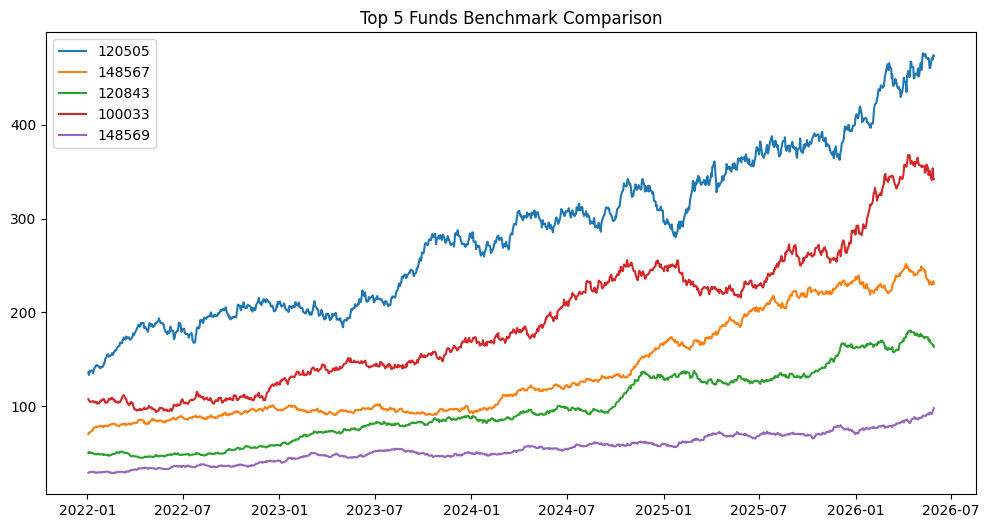

In [26]:
top5 = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()
plt.title("Top 5 Funds Benchmark Comparison")

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()